In [60]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    auc
)
import pickle

In [2]:
# Upload the padding data

X_train_padded = np.load(
    "../Dataset/processed/X_train_padded.npy"
)

X_val_padded = np.load(
    "../Dataset/processed/X_val_padded.npy"
)

X_test_padded = np.load(
    "../Dataset/processed/X_test_padded.npy"
)

y_train = np.load(
    "../Dataset/processed/y_train.npy"
)

y_val = np.load(
    "../Dataset/processed/y_val.npy"
)

y_test = np.load(
    "../Dataset/processed/y_test.npy"
)

In [3]:
ann_best = tf.keras.models.load_model(
    "../models/ann/ann_baseline.keras"
)
rnn_best = tf.keras.models.load_model(
    "../models/rnn/rnn_baseline.keras"
)
lstm_best = tf.keras.models.load_model(
    "../models/lstm/lstm_baseline.keras"
)
gru_best = tf.keras.models.load_model(
    "../models/gru/gru_baseline.keras"
)
bilstm_best = tf.keras.models.load_model(
    "../models/bi_lstm/bi_lstm_baseline.keras"
)

E0000 00:00:1787804493.950555   23793 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
phase6_results = []

In [5]:
# Load TF-IDF Features for ANN

with open(
    "../Dataset/processed/tfidf_vectorizer.pkl",
    "rb"
) as file:

    tfidf_vectorizer = pickle.load(file)

In [6]:
with open(
    "../Dataset/processed/text_splits.pkl",
    "rb"
) as file:

    text_splits = pickle.load(file)

In [7]:
X_train_text = text_splits["X_train"]
X_val_text = text_splits["X_val"]
X_test_text = text_splits["X_test"]

In [8]:
X_train_text

['much say one except probably worst early spate zombie movies may get watch another one revolt zombies month star john carradine intention building army service third reich seen much james baskett uncle remus song south plays leader also serves carradine manservant black comic mantan moreland reprises fraidy cat chauffeur role king zombies exotically named madame sul te wan carradine housekeeper unfortunately carradine supreme achievement zombification wife brings sorts trouble relatives turn remote abode lab inquire sudden death means fake funeral service actually proves disobedient indignant eventually persuading fellow zombies rise master also involved cowboy star bob steele still best known bit howard hawks big sleep plays u secret agent posing nazi posing sheriff thankfully director sekely would much better luck next genre effort day triffids',
 'sure lousy movie intended mockery b western story line filming editing acting plain bad plus music background irritating end loud non s

In [9]:
# Fit already fitted TF-IDF vectorizer

X_train_tfidf = tfidf_vectorizer.transform(
    X_train_text
)

X_val_tfidf = tfidf_vectorizer.transform(
    X_val_text
)

X_test_tfidf = tfidf_vectorizer.transform(
    X_test_text
)

In [10]:
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3592505 stored elements and shape (34705, 20000)>

In [11]:
baseline_metrics = pd.read_csv(
    "../results/metrics/baseline_model_metrics.csv",
    index_col=0
)

baseline_metrics

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANN,0.8744,0.8765,0.8728,0.8746,0.9484
1,RNN,0.4977,0.4998,0.9095,0.6451,0.5000
2,LSTM,0.8653,0.8796,0.8476,0.8633,0.9321
3,GRU,0.8721,0.8690,0.8776,0.8733,0.9353
4,Bi-LSTM,0.8643,0.8661,0.8631,0.8646,0.9358


In [12]:
baseline_predictions = pd.read_csv(
    "../results/metrics/baseline_predictions.csv"
)

baseline_predictions.head()

,Actual,ANN_Probability,ANN_Prediction,RNN_Probability,RNN_Prediction,LSTM_Probability,LSTM_Prediction,GRU_Probability,GRU_Prediction,BiLSTM_Probability,BiLSTM_Prediction
0,1,0.000014,0,0.555182,1,0.961735,1,0.999866,1,0.195447,0
1,0,0.996182,1,0.555051,1,0.003182,0,0.008233,0,0.001881,0
2,0,0.950208,1,0.413207,0,0.000153,0,0.992599,1,0.163316,0
3,0,0.983201,1,0.555540,1,0.947657,1,0.998238,1,0.912420,1
4,1,0.000008,0,0.555340,1,0.995422,1,0.041831,0,0.999731,1


In [13]:
def evaluate_model(y_true, y_pred, y_prob):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [222]:
model_predictions = {
    "ANN": (
        baseline_predictions["ANN_Prediction"].values,
        baseline_predictions["ANN_Probability"].values
    ),
    
    "RNN": (
        baseline_predictions["RNN_Prediction"].values,
        baseline_predictions["RNN_Probability"].values
    ),
    
    "LSTM": (
        baseline_predictions["LSTM_Prediction"].values,
        baseline_predictions["LSTM_Probability"].values
    ),
    
    "GRU": (
        baseline_predictions["GRU_Prediction"].values,
        baseline_predictions["GRU_Probability"].values
    ),
    
    "Bi-LSTM": (
        baseline_predictions["BiLSTM_Prediction"].values,
        baseline_predictions["BiLSTM_Probability"].values
    )
}

In [223]:
model_predictions

{'ANN': (array([0, 1, 1, ..., 0, 1, 1], shape=(7438,)),
  array([1.3790064e-05, 9.9618240e-01, 9.5020753e-01, ..., 5.9911060e-05,
         9.7727920e-01, 9.9995470e-01], shape=(7438,))),
 'RNN': (array([1, 1, 0, ..., 1, 1, 1], shape=(7438,)),
  array([0.55518234, 0.5550513 , 0.41320723, ..., 0.55532753, 0.55556476,
         0.99306476], shape=(7438,))),
 'LSTM': (array([1, 0, 0, ..., 0, 0, 0], shape=(7438,)),
  array([9.6173530e-01, 3.1823078e-03, 1.5257690e-04, ..., 2.9163128e-01,
         3.2335310e-03, 4.0250845e-04], shape=(7438,))),
 'GRU': (array([1, 0, 1, ..., 0, 0, 0], shape=(7438,)),
  array([9.9986630e-01, 8.2333770e-03, 9.9259925e-01, ..., 3.4207232e-02,
         6.6367775e-04, 5.3380774e-07], shape=(7438,))),
 'Bi-LSTM': (array([0, 0, 0, ..., 0, 0, 1], shape=(7438,)),
  array([0.19544739, 0.00188064, 0.16331592, ..., 0.49782586, 0.00405696,
         0.9975889 ], shape=(7438,)))}

In [224]:
# evaluation_results = []

# for model_name, (predictions, probabilities) in model_predictions.items():
    
#     metrics = calculate_metrics(
#         y_test,
#         predictions,
#         probabilities
#     )
    
#     metrics["Model"] = model_name
    
#     evaluation_results.append(metrics)

In [225]:
# evaluation_results

In [226]:
# evaluation_df = pd.DataFrame(
#     evaluation_results
# )

# evaluation_df = evaluation_df[
#     [
#         "Model",
#         "Accuracy",
#         "Precision",
#         "Recall",
#         "F1 Score",
#         "ROC-AUC"
#     ]
# ]

# evaluation_df

In [228]:
# ann_model = tf.keras.models.load_model("../models/ann/ann_lr_scheduler.keras")

In [14]:
ann_probabilities = ann_best.predict(
    X_test_tfidf
).ravel()

233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [15]:
print("y_test shape:", y_test.shape)
print("ANN probabilities shape:", ann_probabilities.shape)

y_test shape: (7438,)
ANN probabilities shape: (7438,)


In [16]:
ann_probabilities

array([1.        , 0.00868362, 0.9999999 , ..., 0.9999947 , 0.999999  ,
       1.        ], shape=(7438,), dtype=float32)

In [17]:
ann_predictions = (
    ann_probabilities.ravel() >= 0.5
).astype(int)

In [18]:
ann_result = evaluate_model(
    y_test,
    ann_predictions,
    ann_probabilities.ravel()
)

phase6_results.append(ann_result)

In [19]:
ann_result

{'Accuracy': 0.8710674912610917,
 'Precision': 0.8684909670563231,
 'Recall': 0.8757031877846236,
 'F1 Score': 0.8720821661998133,
 'ROC-AUC': 0.9442562287769332}

In [ ]:
import pickle

with open('../models/ann/ann_history.pkl', 'rb') as file:
    optimized_history = pickle.load(file)

print(optimized_history)

{'accuracy': [0.8780867457389832, 0.9519953727722168, 0.9756807088851929, 0.9881284832954407, 0.994352400302887, 0.9969168901443481, 0.9965711236000061, 0.9946117401123047, 0.9945828914642334, 0.997377872467041], 'loss': [0.31181010603904724, 0.13710364699363708, 0.07619708776473999, 0.03918090835213661, 0.01801452599465847, 0.009692094288766384, 0.008748356252908707, 0.015105186961591244, 0.014269196428358555, 0.007315448950976133], 'val_accuracy': [0.9018685221672058, 0.8933996558189392, 0.886543869972229, 0.8808979988098145, 0.876730740070343, 0.8747143149375916, 0.8741766214370728, 0.8749831914901733, 0.8749831914901733, 0.8755208849906921], 'val_loss': [0.23703475296497345, 0.27734947204589844, 0.3471579849720001, 0.44227296113967896, 0.5931910872459412, 0.7170290350914001, 0.7754197716712952, 0.7698379158973694, 0.7712756395339966, 0.8562280535697937]}


In [50]:
optimized_history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

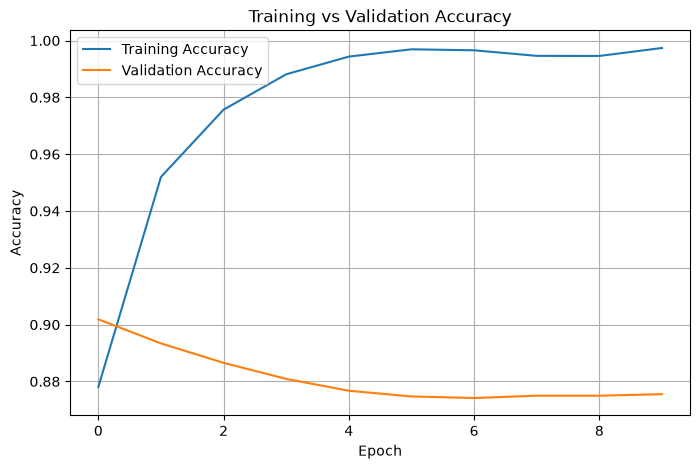

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    optimized_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    optimized_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

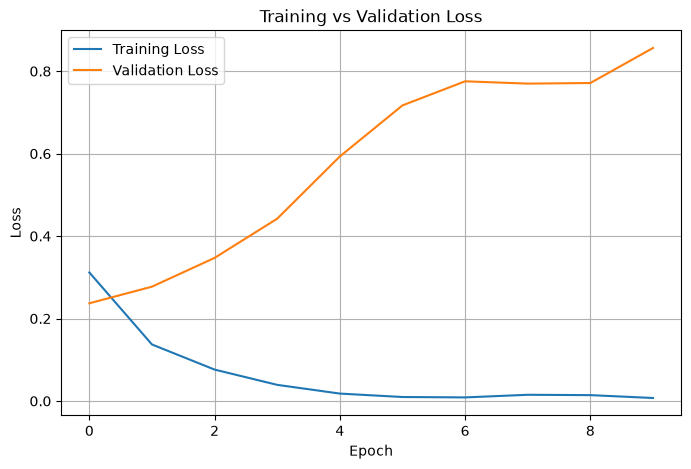

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    optimized_history["loss"],
    label="Training Loss"
)

plt.plot(
    optimized_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [36]:
cm = confusion_matrix(
    y_test,
    ann_predictions
)

cm

array([[3210,  495],
       [ 464, 3269]])

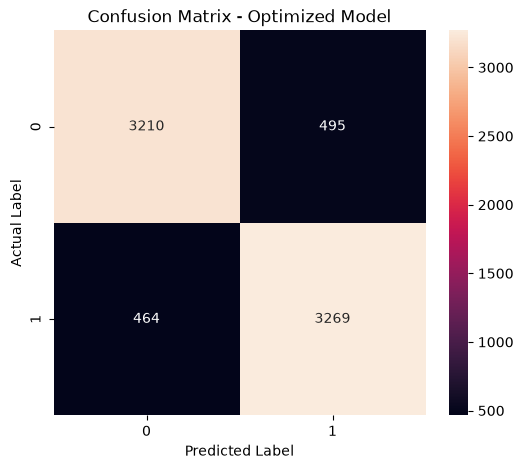

In [37]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Optimized Model")

plt.show()

In [57]:
fpr, tpr, thresholds = roc_curve(y_test, ann_probabilities)

auc_score = roc_auc_score(y_test, ann_probabilities)

print("ROC AUC:", auc_score)

ROC AUC: 0.9442562287769332


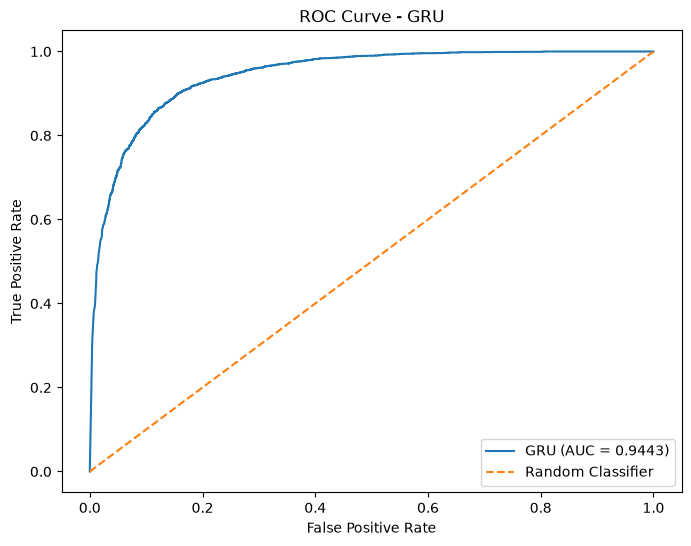

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(fpr,tpr,label=f"GRU (AUC = {auc_score:.4f})")

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GRU")
plt.legend()
plt.show()

In [61]:
precision, recall, thresholds = precision_recall_curve(y_test,ann_probabilities)

ap_score = average_precision_score(y_test,ann_probabilities)

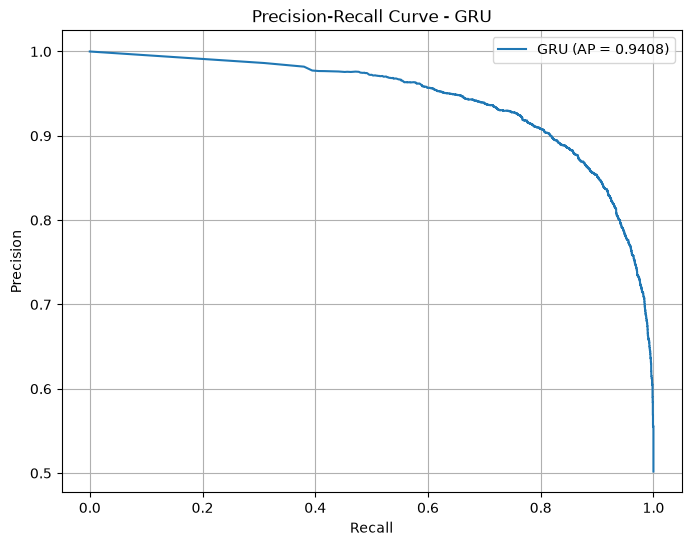

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(recall,precision,label=f"GRU (AP = {ap_score:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - GRU")
plt.legend()
plt.grid()

plt.show()

In [64]:
misclassified_mask = (
    y_test != ann_predictions
)

In [ ]:
misclassified_indices = np.where(
    misclassified_mask
)[0]

In [66]:
misclassified_indices

array([   2,    4,    5,    6,    7,   30,   33,   39,   46,   58,   59,
         60,   66,   78,   81,   84,   87,   90,   91,  114,  126,  127,
        134,  146,  148,  155,  168,  179,  180,  186,  193,  194,  202,
        212,  213,  218,  219,  232,  237,  240,  247,  249,  256,  272,
        276,  286,  291,  304,  309,  319,  331,  339,  349,  358,  359,
        361,  384,  397,  398,  400,  401,  418,  432,  458,  460,  463,
        470,  478,  480,  511,  513,  514,  526,  537,  544,  556,  561,
        564,  575,  579,  582,  593,  597,  603,  624,  634,  637,  644,
        652,  655,  663,  669,  677,  685,  701,  706,  708,  731,  732,
        738,  749,  750,  756,  793,  803,  808,  845,  850,  851,  857,
        864,  872,  906,  907,  908,  914,  925,  929,  930,  936,  941,
        945,  964,  965,  975,  981,  982,  983, 1001, 1006, 1010, 1017,
       1027, 1031, 1038, 1055, 1057, 1059, 1074, 1076, 1077, 1083, 1089,
       1095, 1117, 1134, 1145, 1147, 1155, 1159, 11

In [ ]:
print(
    "Number of misclassified reviews:",
    len(misclassified_indices)
)

Number of misclassified reviews: 959


In [68]:
misclassified_reviews = pd.DataFrame({
    "Review": np.array(y_test)[
        misclassified_indices
    ],
    
    "Actual": y_test[
        misclassified_indices
    ],
    
    "Predicted": ann_predictions[
        misclassified_indices
    ],
    
    "Probability": ann_probabilities[
        misclassified_indices
    ]
})

In [ ]:
misclassified_reviews["Actual"] = (
    misclassified_reviews["Actual"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

misclassified_reviews["Predicted"] = (
    misclassified_reviews["Predicted"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

In [70]:
misclassified_reviews.head()

,Review,Actual,Predicted,Probability
0,0,Negative,Positive,1.000000
1,1,Positive,Negative,0.023752
2,1,Positive,Negative,0.120442
3,0,Negative,Positive,0.884854
4,0,Negative,Positive,0.945484


In [ ]:
misclassified_reviews.to_csv(
    "../results/metrics/misclassified_reviews_ann.csv",
    index=False
)

In [23]:
rnn_model = tf.keras.models.load_model(
    "../models/rnn/rnn_baseline.keras"
)

rnn_probabilities = rnn_model.predict(
    X_test_padded
).ravel()

rnn_predictions = (
    rnn_probabilities >= 0.5
).astype(int)

rnn_result = evaluate_model(
    y_test,
    rnn_predictions,
    rnn_probabilities.ravel()
)

phase6_results.append(rnn_result)

233/233 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step


In [24]:
rnn_result

{'Accuracy': 0.4977144393654208,
 'Precision': 0.4997791844545856,
 'Recall': 0.9094562014465577,
 'F1 Score': 0.6450693520805624,
 'ROC-AUC': 0.50002244995125}

In [72]:
with open('../models/rnn/rnn_history.pkl', 'rb') as file:
    rnn_history = pickle.load(file)

print(rnn_history)

{'accuracy': [0.5030398964881897, 0.5462901592254639, 0.5789079666137695, 0.5714450478553772, 0.5819046497344971, 0.5841233134269714, 0.5863996744155884, 0.5872929096221924, 0.5881285071372986, 0.5907794237136841], 'loss': [0.6958521008491516, 0.6598554849624634, 0.598922073841095, 0.6179037094116211, 0.5922264456748962, 0.5849352478981018, 0.5934887528419495, 0.5870496034622192, 0.5863662362098694, 0.5835149884223938], 'val_accuracy': [0.49993279576301575, 0.4976475238800049, 0.5096114873886108, 0.4980508089065552, 0.49818524718284607, 0.4942868649959564, 0.5070574283599854, 0.505981981754303, 0.5002016425132751, 0.4949589967727661], 'val_loss': [0.6946058869361877, 0.7275991439819336, 0.7684146165847778, 0.7839159965515137, 0.8062504529953003, 0.7975813150405884, 0.8273557424545288, 0.8558428287506104, 0.8652355074882507, 0.872343897819519]}


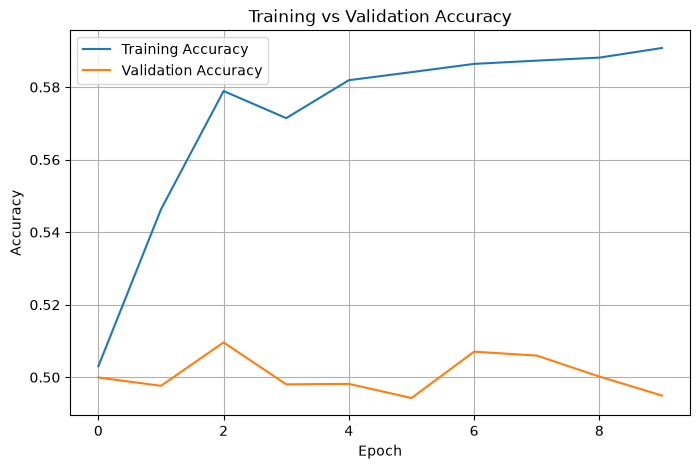

In [73]:
plt.figure(figsize=(8, 5))

plt.plot(
    rnn_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    rnn_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

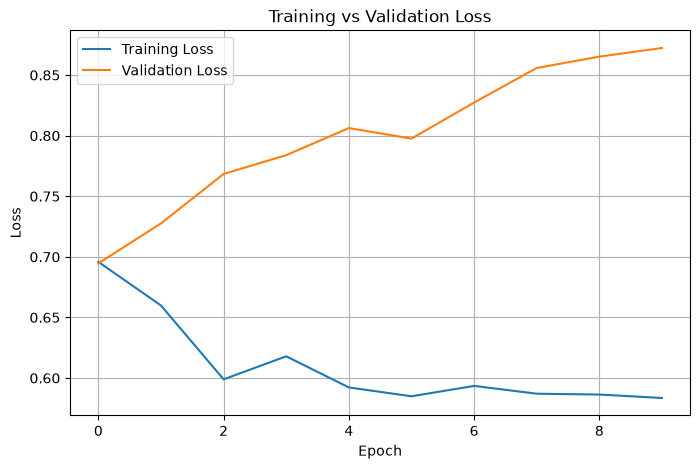

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    rnn_history["loss"],
    label="Training Loss"
)

plt.plot(
    rnn_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [39]:
cm_rnn = confusion_matrix(
    y_test,
    rnn_predictions
)

cm_rnn

array([[ 307, 3398],
       [ 338, 3395]])

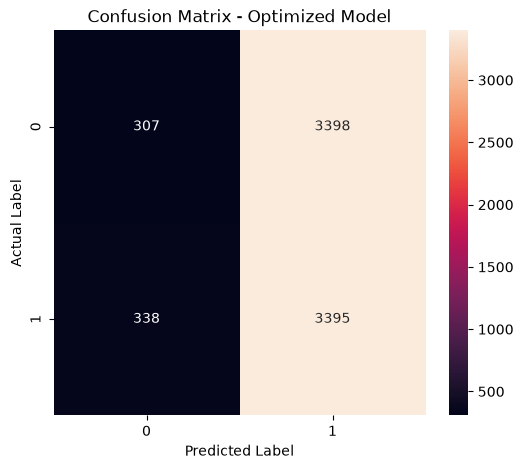

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rnn,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Optimized Model")

plt.show()

In [75]:
fpr, tpr, thresholds = roc_curve(y_test, rnn_probabilities)

auc_score = roc_auc_score(y_test, rnn_probabilities)

print("ROC AUC:", auc_score)

ROC AUC: 0.50002244995125


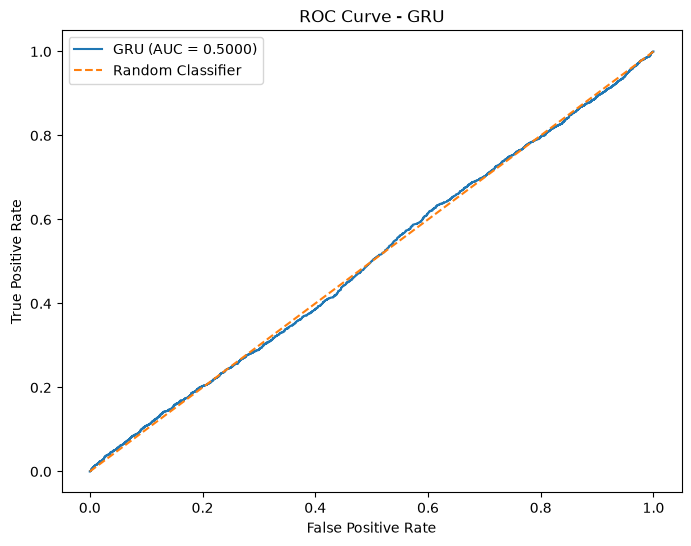

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(fpr,tpr,label=f"GRU (AUC = {auc_score:.4f})")

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GRU")
plt.legend()
plt.show()

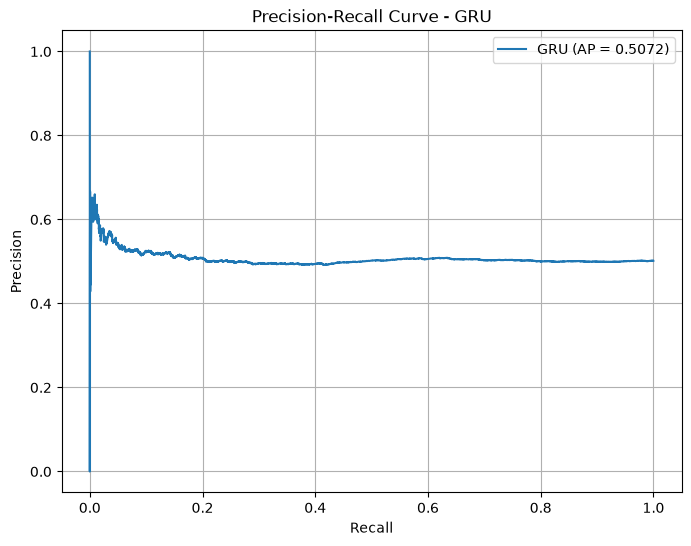

In [77]:
precision, recall, thresholds = precision_recall_curve(y_test,rnn_probabilities)

ap_score = average_precision_score(y_test,rnn_probabilities)

plt.figure(figsize=(8, 6))

plt.plot(recall,precision,label=f"GRU (AP = {ap_score:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - GRU")
plt.legend()
plt.grid()

plt.show()

In [79]:
misclassified_mask = (
    y_test != rnn_predictions
)

misclassified_indices = np.where(
    misclassified_mask
)[0]

print(
    "Number of misclassified reviews:",
    len(misclassified_indices)
)

Number of misclassified reviews: 3736


In [80]:
misclassified_reviews = pd.DataFrame({
    "Review": np.array(y_test)[
        misclassified_indices
    ],
    
    "Actual": y_test[
        misclassified_indices
    ],
    
    "Predicted": rnn_predictions[
        misclassified_indices
    ],
    
    "Probability": rnn_probabilities[
        misclassified_indices
    ]
})

misclassified_reviews["Actual"] = (
    misclassified_reviews["Actual"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

misclassified_reviews["Predicted"] = (
    misclassified_reviews["Predicted"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

In [81]:
misclassified_reviews.to_csv(
    "../results/metrics/misclassified_reviews_rnn.csv",
    index=False
)

# LSTM

In [27]:
lstm_model = tf.keras.models.load_model(
    "../models/lstm/lstm_baseline.keras"
)

lstm_prob = lstm_model.predict(
    X_test_padded
).ravel()

lstm_pred = (
    lstm_prob >= 0.5
).astype(int)

lstm_result = evaluate_model(
    y_test,
    lstm_pred,
    lstm_prob.ravel()
)

phase6_results.append(lstm_result)

233/233 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step


In [82]:
with open('../models/lstm/lstm_history.pkl', 'rb') as file:
    lstm_history = pickle.load(file)

print(lstm_history)

{'accuracy': [0.535484790802002, 0.5551361441612244, 0.6300532817840576, 0.8535369634628296, 0.9379916191101074, 0.9643279314041138, 0.9812130928039551, 0.9898285269737244, 0.992018461227417, 0.9938625693321228], 'loss': [0.6830403208732605, 0.6629817485809326, 0.6058110594749451, 0.3299461603164673, 0.17963892221450806, 0.11759315431118011, 0.07181180268526077, 0.04717141389846802, 0.03712768480181694, 0.029802633449435234], 'val_accuracy': [0.538244366645813, 0.5313886404037476, 0.5406640768051147, 0.8846619129180908, 0.8839898109436035, 0.8787471652030945, 0.8757897615432739, 0.873638927936554, 0.8701438307762146, 0.8741766214370728], 'val_loss': [0.6797462701797485, 0.678955614566803, 0.674906313419342, 0.295832097530365, 0.31057679653167725, 0.35555702447891235, 0.42515748739242554, 0.4943903684616089, 0.5321939587593079, 0.5637558102607727]}


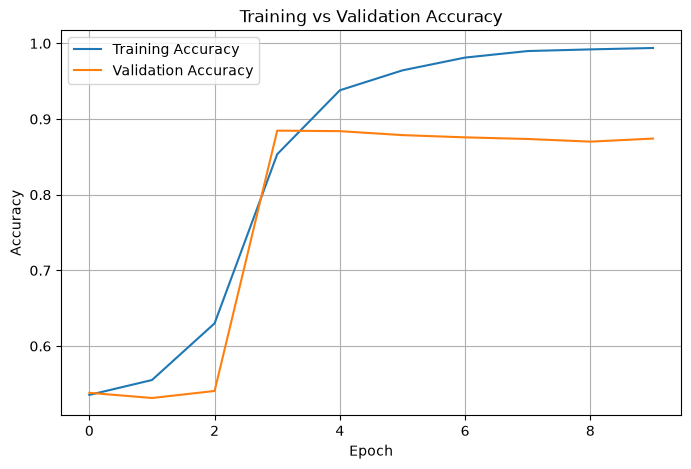

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    lstm_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    lstm_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

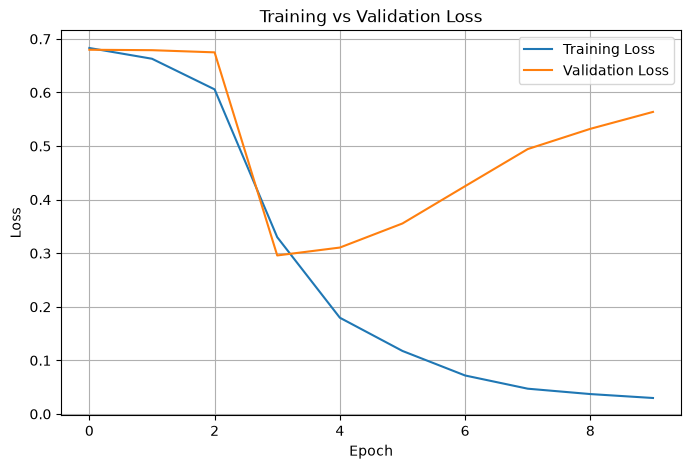

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    lstm_history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

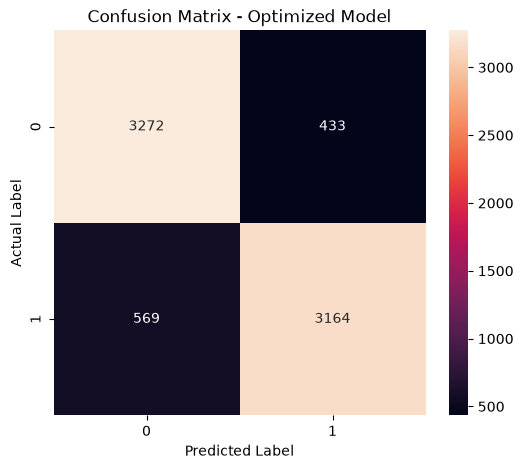

In [42]:
cm_lstm = confusion_matrix(
    y_test,
    lstm_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Optimized Model")

plt.show()

In [43]:
lstm_result

{'Accuracy': 0.8652863673030384,
 'Precision': 0.8796219071448429,
 'Recall': 0.8475756763996786,
 'F1 Score': 0.8633015006821282,
 'ROC-AUC': 0.9320514085807979}

ROC AUC: 0.9320514085807979


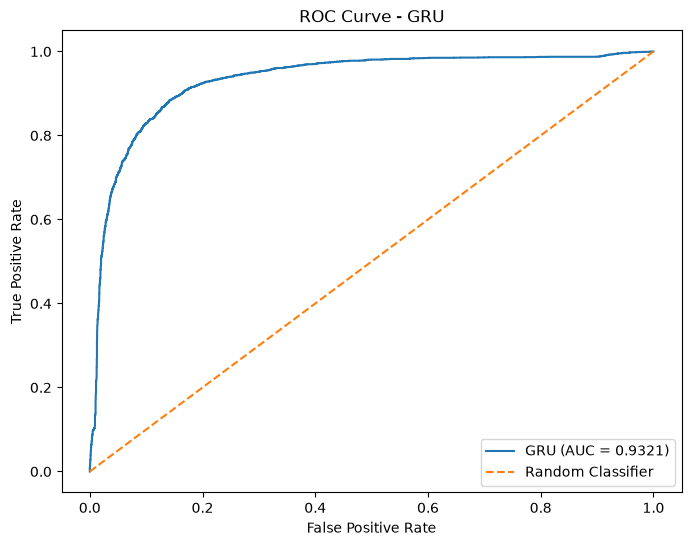

In [86]:
fpr, tpr, thresholds = roc_curve(y_test, lstm_prob)

auc_score = roc_auc_score(y_test, lstm_prob)

print("ROC AUC:", auc_score)

plt.figure(figsize=(8, 6))

plt.plot(fpr,tpr,label=f"GRU (AUC = {auc_score:.4f})")

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GRU")
plt.legend()
plt.show()

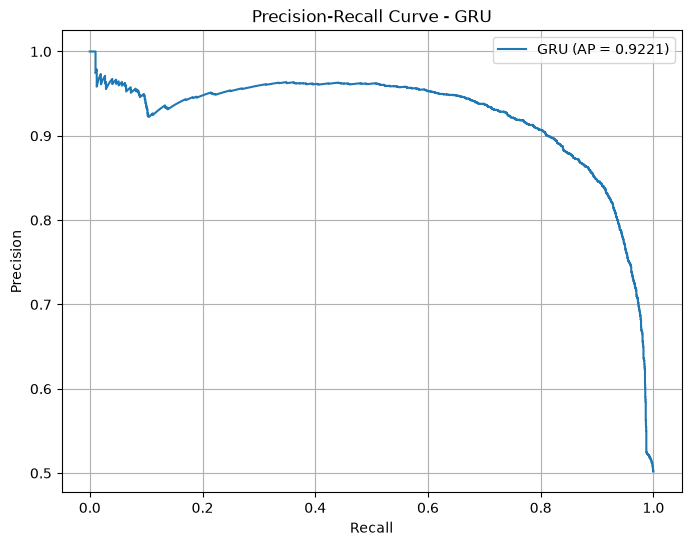

In [87]:
precision, recall, thresholds = precision_recall_curve(y_test,lstm_prob)

ap_score = average_precision_score(y_test,lstm_prob)

plt.figure(figsize=(8, 6))

plt.plot(recall,precision,label=f"GRU (AP = {ap_score:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - GRU")
plt.legend()
plt.grid()

plt.show()

In [89]:
misclassified_mask = (
    y_test != lstm_pred
)

misclassified_indices = np.where(
    misclassified_mask
)[0]

print(
    "Number of misclassified reviews:",
    len(misclassified_indices)
)

Number of misclassified reviews: 1002


In [90]:
misclassified_reviews = pd.DataFrame({
    "Review": np.array(y_test)[
        misclassified_indices
    ],
    
    "Actual": y_test[
        misclassified_indices
    ],
    
    "Predicted": lstm_pred[
        misclassified_indices
    ],
    
    "Probability": lstm_prob[
        misclassified_indices
    ]
})

misclassified_reviews["Actual"] = (
    misclassified_reviews["Actual"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

misclassified_reviews["Predicted"] = (
    misclassified_reviews["Predicted"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

In [91]:
misclassified_reviews.head()

,Review,Actual,Predicted,Probability
0,0,Negative,Positive,0.635362
1,0,Negative,Positive,0.997538
2,1,Positive,Negative,0.012119
3,0,Negative,Positive,0.614146
4,0,Negative,Positive,0.934728


In [92]:
misclassified_reviews.to_csv(
    "../results/metrics/misclassified_reviews_lstm.csv",
    index=False
)

In [44]:
gru_model = tf.keras.models.load_model(
    "../models/gru/gru_baseline.keras"
)

gru_prob = gru_model.predict(
    X_test_padded,
    verbose=0
).ravel()

gru_pred = (
    gru_prob >= 0.5
).astype(int)

gru_result = evaluate_model(
    y_test,
    gru_pred,
    gru_prob.ravel()
)

In [94]:
with open('../models/gru/gru_history.pkl', 'rb') as file:
    gru_history = pickle.load(file)

print(gru_history)

{'accuracy': [0.5065264105796814, 0.6189886331558228, 0.9012246131896973, 0.9562022686004639, 0.9813571572303772, 0.9912404417991638, 0.9945541024208069, 0.9965134859085083, 0.9972914457321167, 0.9982423186302185], 'loss': [0.6924229264259338, 0.5952985286712646, 0.25380390882492065, 0.13047823309898376, 0.0616891123354435, 0.029972214251756668, 0.01983252353966236, 0.013961729593575, 0.009148959070444107, 0.0077484846115112305], 'val_accuracy': [0.5235918760299683, 0.8587175607681274, 0.8818389773368835, 0.8882914185523987, 0.8780750036239624, 0.8780750036239624, 0.8753864765167236, 0.8776717185974121, 0.852130651473999, 0.8748487830162048], 'val_loss': [0.6867899298667908, 0.3464071452617645, 0.28035393357276917, 0.3065330386161804, 0.3924412727355957, 0.5070755481719971, 0.5894367098808289, 0.6447165012359619, 0.6779930591583252, 0.7059733867645264]}


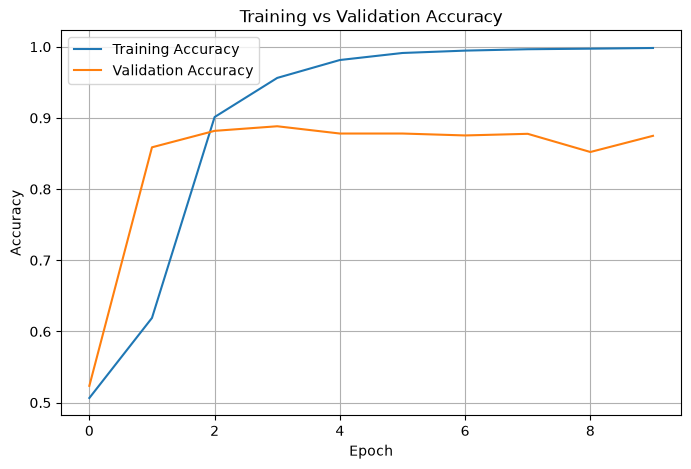

In [97]:
plt.figure(figsize=(8, 5))

plt.plot(
    gru_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    gru_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

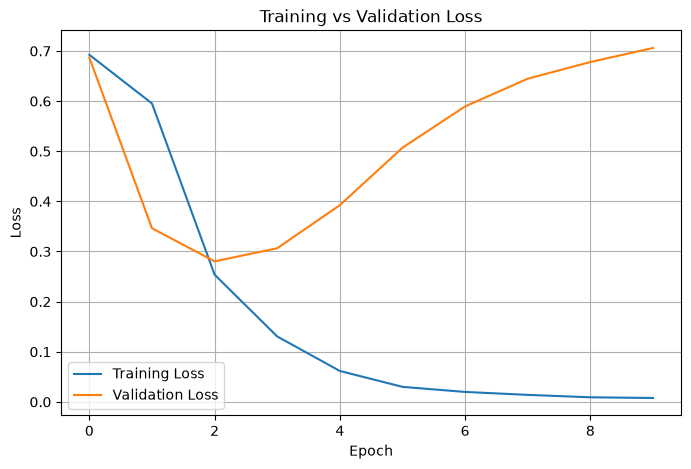

In [98]:
plt.figure(figsize=(8, 5))

plt.plot(
    gru_history["loss"],
    label="Training Loss"
)

plt.plot(
    gru_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

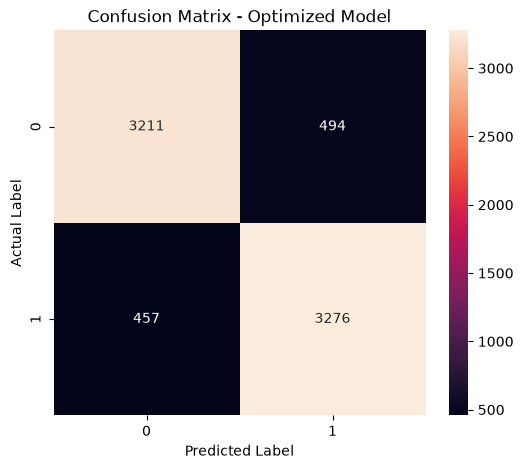

In [45]:
cm_gru = confusion_matrix(
    y_test,
    gru_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_gru,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Optimized Model")

plt.show()

ROC AUC: 0.9352575219085855


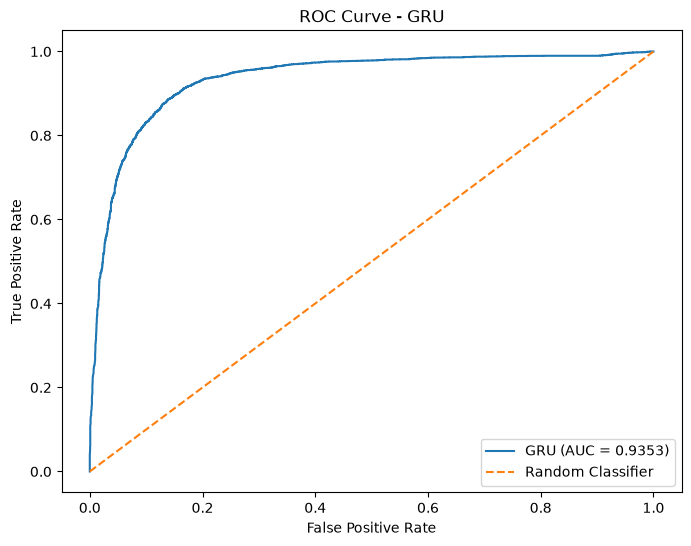

In [99]:
fpr, tpr, thresholds = roc_curve(y_test, gru_prob)

auc_score = roc_auc_score(y_test, gru_prob)

print("ROC AUC:", auc_score)

plt.figure(figsize=(8, 6))

plt.plot(fpr,tpr,label=f"GRU (AUC = {auc_score:.4f})")

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GRU")
plt.legend()
plt.show()

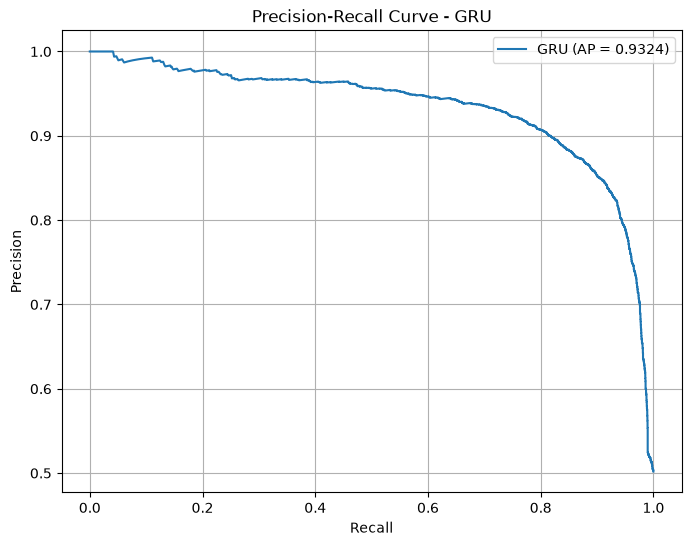

In [100]:
precision, recall, thresholds = precision_recall_curve(y_test,gru_prob)

ap_score = average_precision_score(y_test,gru_prob)

plt.figure(figsize=(8, 6))

plt.plot(recall,precision,label=f"GRU (AP = {ap_score:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - GRU")
plt.legend()
plt.grid()

plt.show()

In [101]:
misclassified_mask = (
    y_test != gru_pred
)

misclassified_indices = np.where(
    misclassified_mask
)[0]

print(
    "Number of misclassified reviews:",
    len(misclassified_indices)
)

Number of misclassified reviews: 951


In [102]:
misclassified_reviews = pd.DataFrame({
    "Review": np.array(y_test)[
        misclassified_indices
    ],
    
    "Actual": y_test[
        misclassified_indices
    ],
    
    "Predicted": gru_pred[
        misclassified_indices
    ],
    
    "Probability": gru_prob[
        misclassified_indices
    ]
})

misclassified_reviews["Actual"] = (
    misclassified_reviews["Actual"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

misclassified_reviews["Predicted"] = (
    misclassified_reviews["Predicted"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

In [103]:
misclassified_reviews.head()

,Review,Actual,Predicted,Probability
0,0,Negative,Positive,0.999994
1,0,Negative,Positive,0.980775
2,0,Negative,Positive,0.997701
3,0,Negative,Positive,0.999976
4,1,Positive,Negative,0.002746


In [31]:
phase6_results.append(gru_result)

In [32]:
gru_result

{'Accuracy': 0.872143049206776,
 'Precision': 0.8689655172413793,
 'Recall': 0.8775783552102866,
 'F1 Score': 0.8732506997201119,
 'ROC-AUC': 0.9352575219085855}

In [104]:
misclassified_reviews.to_csv(
    "../results/metrics/misclassified_reviews_gru.csv",
    index=False
)

In [33]:
bi_lstm_model = tf.keras.models.load_model(
    "../models/bi_lstm/bi_lstm_baseline.keras"
)

bi_lstm_prob = bi_lstm_model.predict(
    X_test_padded,
    verbose=0
).ravel()

bi_lstm_pred = (
    bi_lstm_prob >= 0.5
).astype(int)

bilstm_result = evaluate_model(
    y_test,
    bi_lstm_pred,
    bi_lstm_prob.ravel()
)

In [34]:
phase6_results.append(bilstm_result)

In [106]:
with open('../models/bi_lstm/bi_lstm_history.pkl', 'rb') as file:
    bi_lstm_history = pickle.load(file)

print(bi_lstm_history)

{'accuracy': [0.8339143991470337, 0.9251692891120911, 0.954012393951416, 0.9647601246833801, 0.9788791537284851, 0.9869471192359924, 0.9899150133132935, 0.9918455481529236, 0.9907793998718262, 0.9933438897132874], 'loss': [0.37680551409721375, 0.20390461385250092, 0.1281212568283081, 0.10203836858272552, 0.06527788937091827, 0.04128338769078255, 0.03264687955379486, 0.025996048003435135, 0.029422570019960403, 0.022164223715662956], 'val_accuracy': [0.8876193165779114, 0.8853340744972229, 0.8835865259170532, 0.8735045194625854, 0.871219277381897, 0.8726979494094849, 0.8687995672225952, 0.8739078044891357, 0.8600618243217468, 0.8631536364555359], 'val_loss': [0.28470781445503235, 0.2893880009651184, 0.3458516299724579, 0.35629886388778687, 0.4458707571029663, 0.5682555437088013, 0.5441843867301941, 0.6690449714660645, 0.5284140706062317, 0.6180019974708557]}


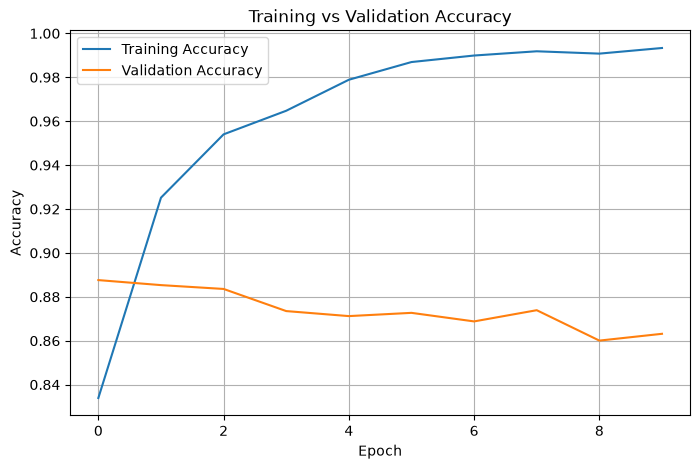

In [107]:
plt.figure(figsize=(8, 5))

plt.plot(
    bi_lstm_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    bi_lstm_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

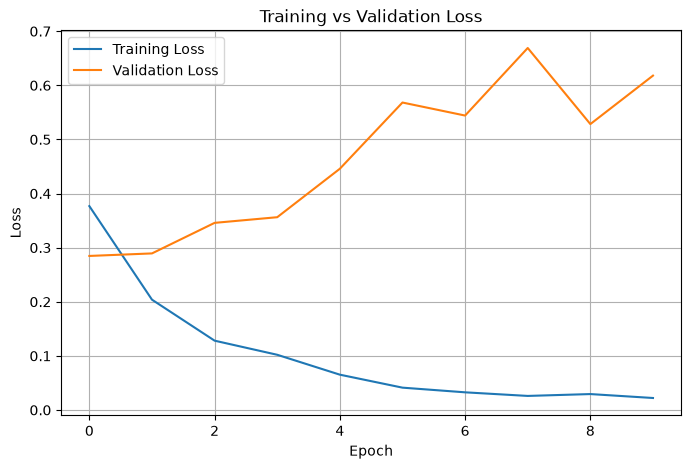

In [108]:

plt.figure(figsize=(8, 5))

plt.plot(
    bi_lstm_history["loss"],
    label="Training Loss"
)

plt.plot(
    bi_lstm_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

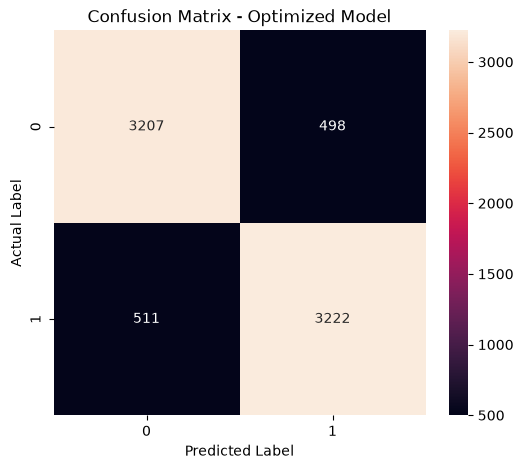

In [46]:
cm_bilstm = confusion_matrix(
    y_test,
    bi_lstm_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bilstm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Optimized Model")

plt.show()

ROC AUC: 0.9358436789288228


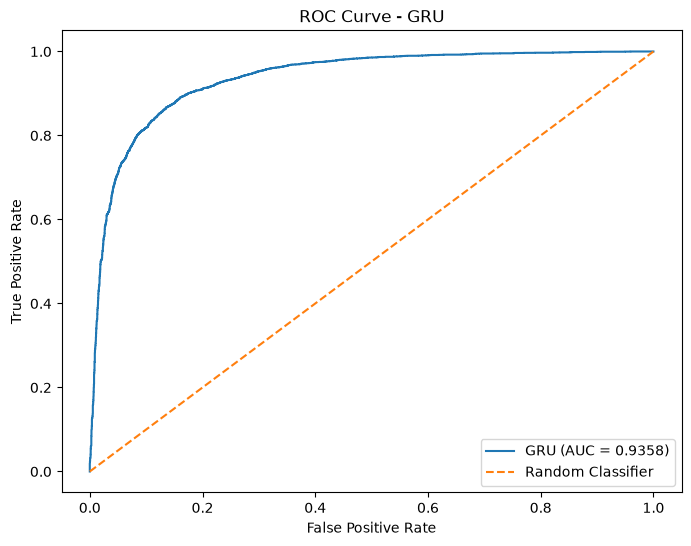

In [109]:
fpr, tpr, thresholds = roc_curve(y_test, bi_lstm_prob)

auc_score = roc_auc_score(y_test, bi_lstm_prob)

print("ROC AUC:", auc_score)

plt.figure(figsize=(8, 6))

plt.plot(fpr,tpr,label=f"GRU (AUC = {auc_score:.4f})")

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GRU")
plt.legend()
plt.show()

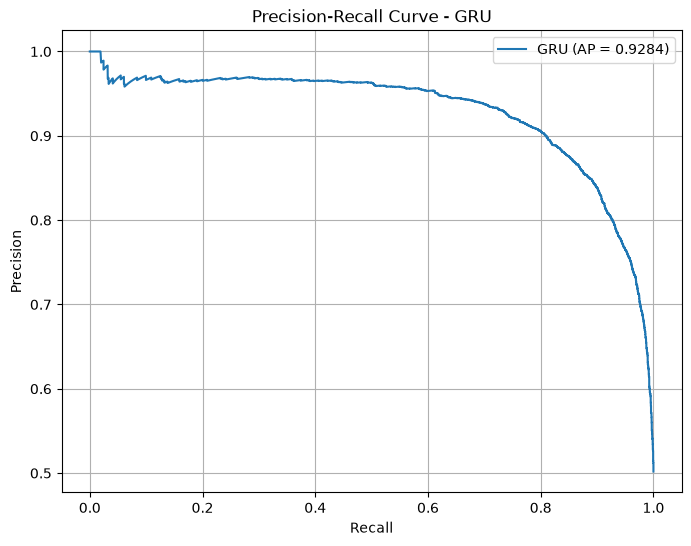

In [110]:
precision, recall, thresholds = precision_recall_curve(y_test,bi_lstm_prob)

ap_score = average_precision_score(y_test,bi_lstm_prob)

plt.figure(figsize=(8, 6))

plt.plot(recall,precision,label=f"GRU (AP = {ap_score:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - GRU")
plt.legend()
plt.grid()

plt.show()

In [111]:
misclassified_mask = (
    y_test != bi_lstm_pred
)

misclassified_indices = np.where(
    misclassified_mask
)[0]

print(
    "Number of misclassified reviews:",
    len(misclassified_indices)
)

Number of misclassified reviews: 1009


In [112]:
misclassified_reviews = pd.DataFrame({
    "Review": np.array(y_test)[
        misclassified_indices
    ],
    
    "Actual": y_test[
        misclassified_indices
    ],
    
    "Predicted": bi_lstm_pred[
        misclassified_indices
    ],
    
    "Probability": bi_lstm_prob[
        misclassified_indices
    ]
})

misclassified_reviews["Actual"] = (
    misclassified_reviews["Actual"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

misclassified_reviews["Predicted"] = (
    misclassified_reviews["Predicted"]
    .map({
        0: "Negative",
        1: "Positive"
    })
)

In [113]:
misclassified_reviews.head()

,Review,Actual,Predicted,Probability
0,0,Negative,Positive,0.867878
1,0,Negative,Positive,0.965858
2,0,Negative,Positive,0.984984
3,0,Negative,Positive,0.988592
4,0,Negative,Positive,0.866330


In [47]:
bilstm_result

{'Accuracy': 0.8643452541005646,
 'Precision': 0.8661290322580645,
 'Recall': 0.8631127779266006,
 'F1 Score': 0.8646182745203274,
 'ROC-AUC': 0.9358436789288228}

In [114]:
misclassified_reviews.to_csv(
    "../results/metrics/misclassified_reviews_bi_lstm.csv",
    index=False
)